In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
!pip install pandas openpyxl

zsh:1: command not found: pip


In [2]:
data_area_harvested = pd.read_excel('../data/raw_cotton_data/AREA_HARVESTED.xlsx', usecols=['location_desc', 'year', 'Value'])
data_area_planted = pd.read_excel('../data/raw_cotton_data/AREA_PLANTED.xlsx', usecols=['location_desc', 'year', 'Value'])
data_yield = pd.read_excel('../data/raw_cotton_data/YIELD.xlsx', usecols=['location_desc', 'year', 'Value'])

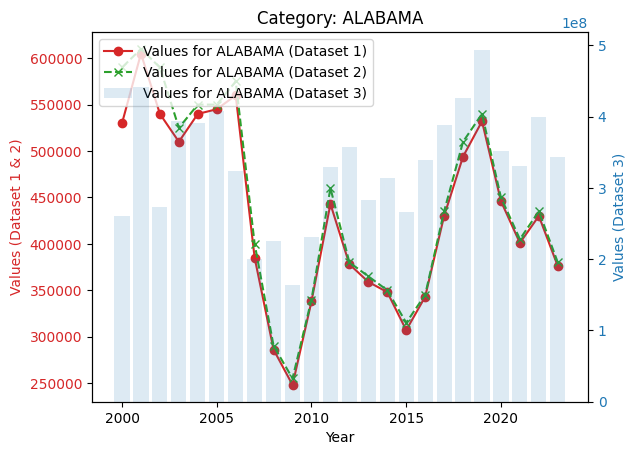

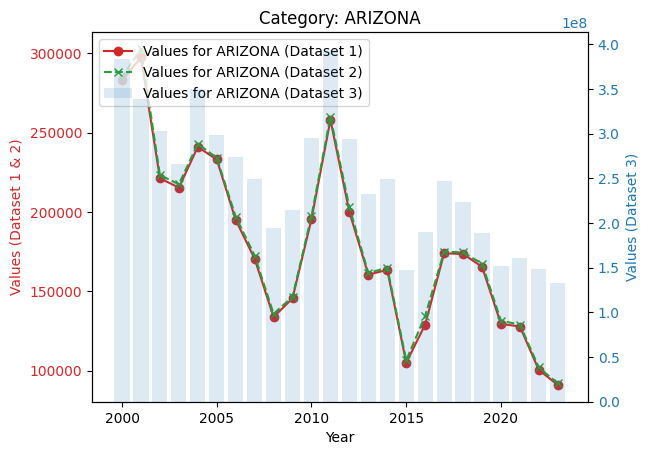

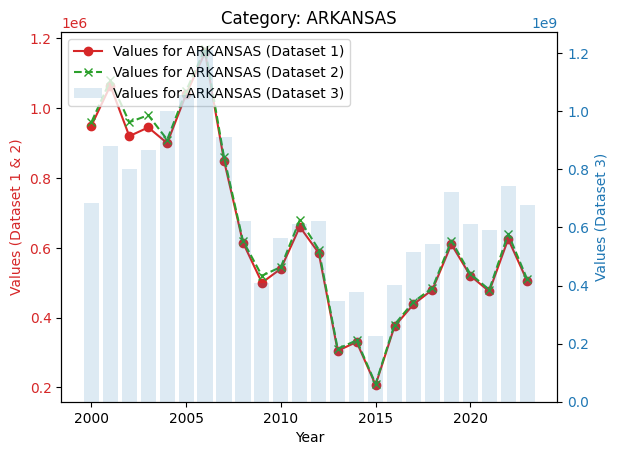

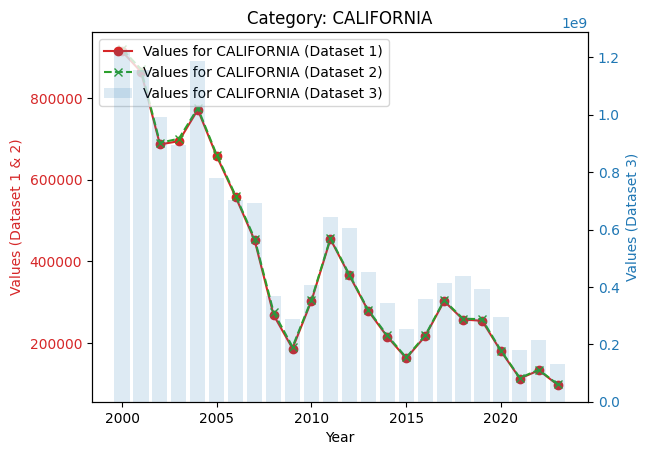

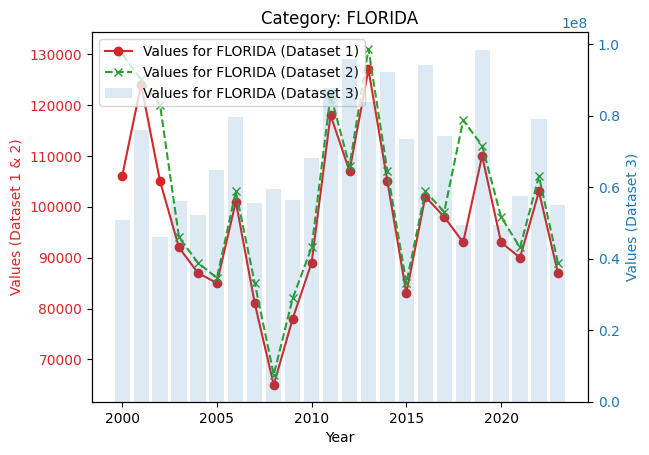

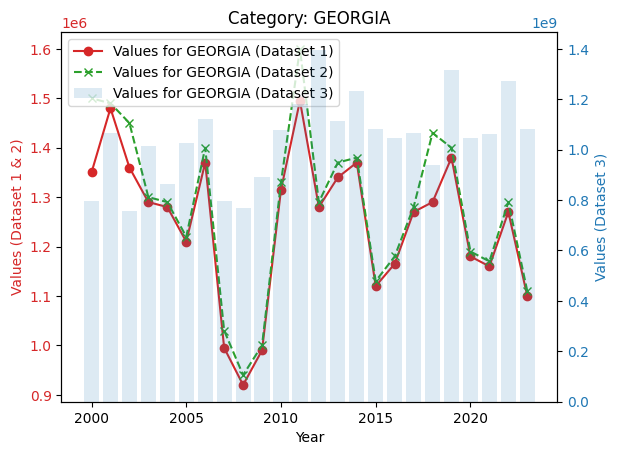

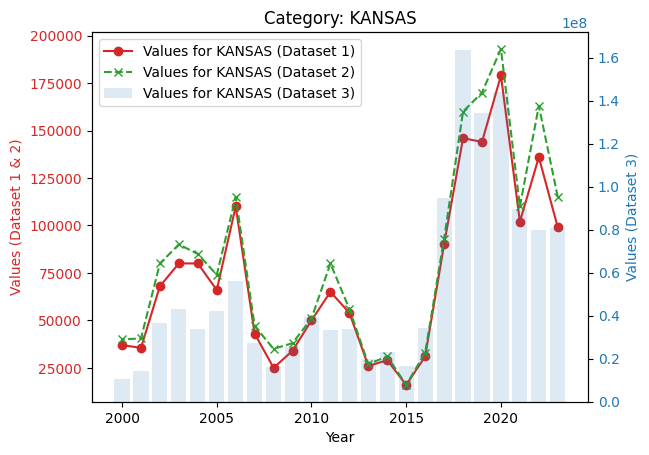

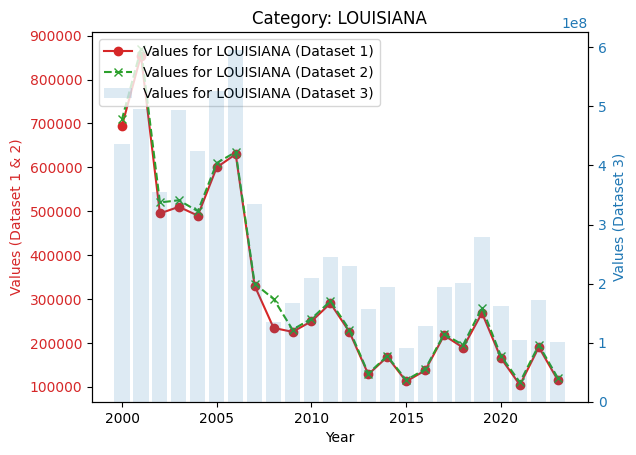

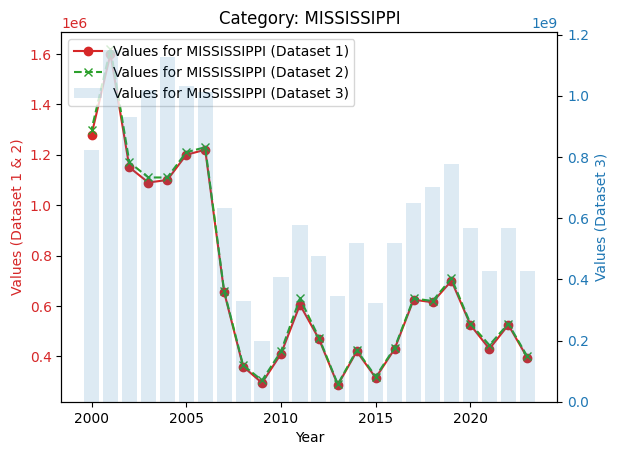

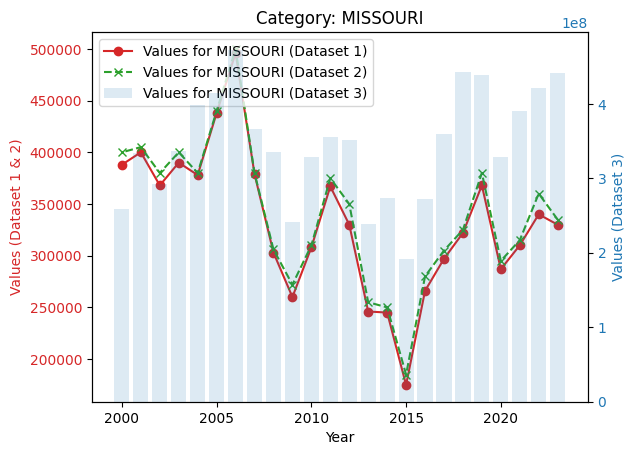

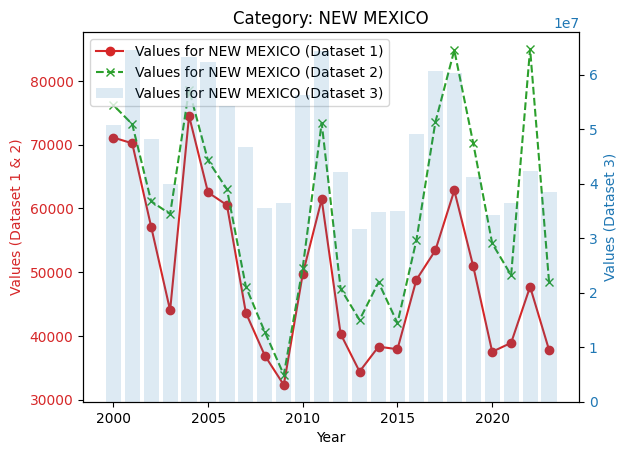

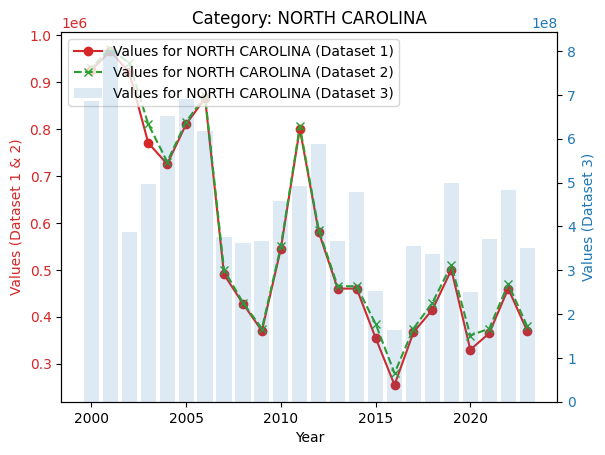

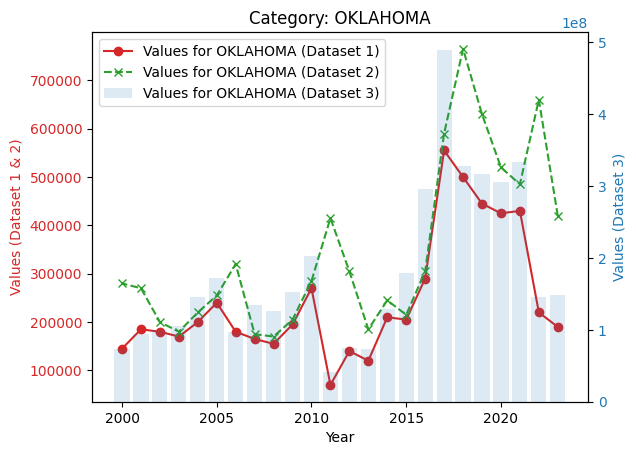

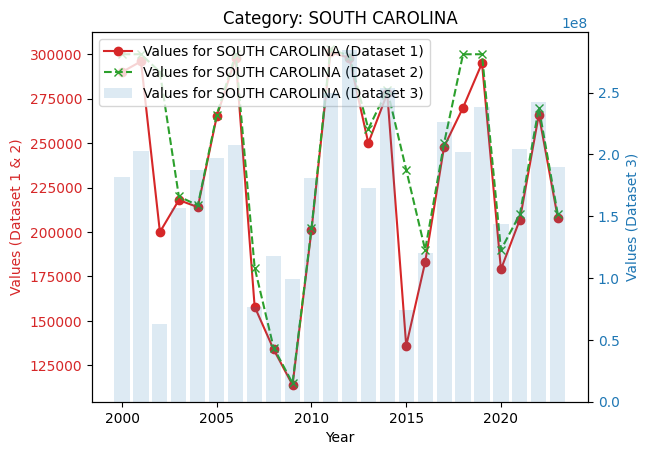

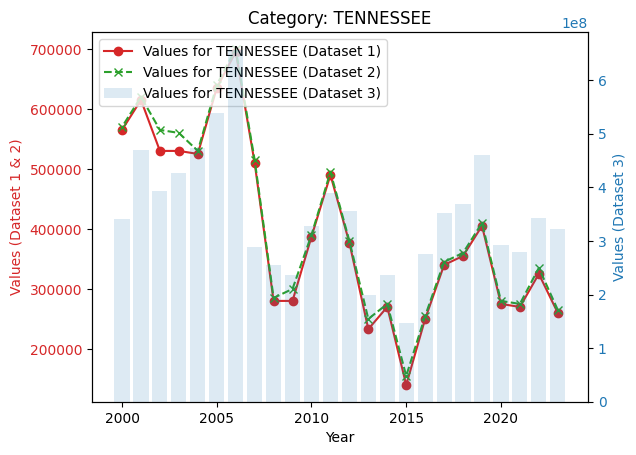

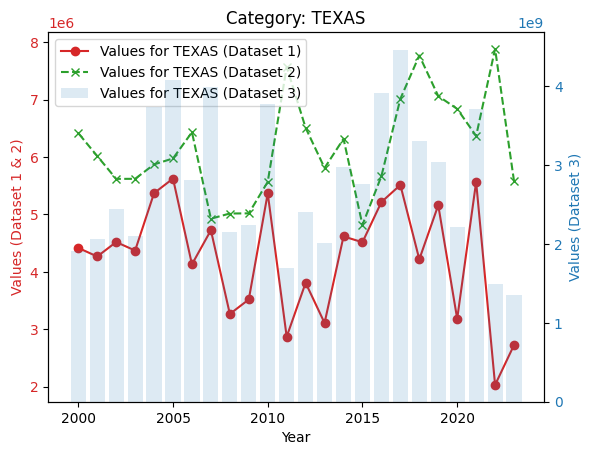

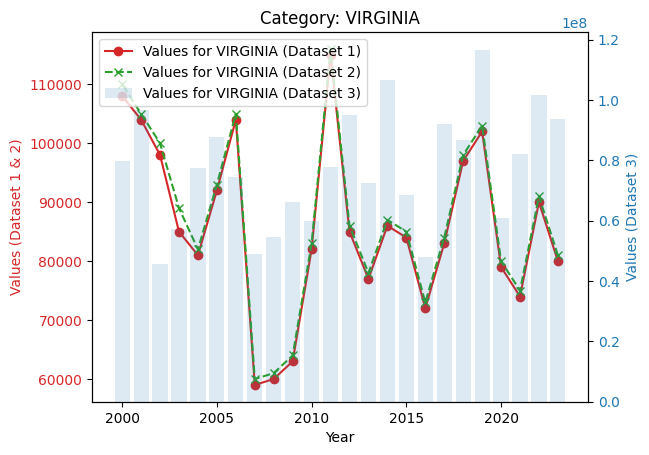

[array([376000., 430000., 401000., 446000., 532000., 494000., 430000.,
       343000., 307000., 348000., 359000., 378000., 443000., 338000.,
       248000., 286000., 385000., 560000., 545000., 540000., 510000.,
       540000., 605000., 530000.]), array([ 91000., 100400., 127800., 129500., 165500., 173500., 174000.,
       129000., 105000., 163500., 160500., 200000., 258000., 195500.,
       145600., 133800., 170500., 195000., 233100., 241000., 215400.,
       221200., 297500., 282900.]), array([ 505000.,  625000.,  475000.,  520000.,  610000.,  480000.,
        438000.,  375000.,  207000.,  330000.,  305000.,  585000.,
        660000.,  540000.,  500000.,  615000.,  850000., 1160000.,
       1040000.,  900000.,  945000.,  920000., 1065000.,  950000.]), array([ 96800., 132500., 112500., 179500., 254000., 257000., 302000.,
       216000., 162000., 215000., 278000., 365000., 454000., 303000.,
       186000., 268000., 451000., 557000., 657000., 771000., 694000.,
       686000., 864000., 91

In [3]:
grouped_data_area_harvested = data_area_harvested.groupby('location_desc')
grouped_data_area_planted = data_area_planted.groupby('location_desc')
grouped_data_yield = data_yield.groupby('location_desc')

def plot_function(grouped1, grouped2, grouped3):
    # Ensure the group names match and are in the same order for all groupby objects
    keys1 = grouped1.groups.keys()
    keys2 = grouped2.groups.keys()
    keys3 = grouped3.groups.keys()

    common_keys = sorted(set(keys1) & set(keys2) & set(keys3))

    harvested_area_sums = []
    planted_area_sums = []
    yield_sums = []
    categories = []  # To keep track of the keys/categories

    for key in common_keys:
        group_df1 = grouped1.get_group(key)
        group_df2 = grouped2.get_group(key)
        group_df3 = grouped3.get_group(key)

        fig, ax1 = plt.subplots()
        plt.title(f"Category: {key}")

        color1 = 'tab:red'
        ax1.plot(group_df1['year'], group_df1['Value'].str.replace(',', '').astype(float),
                 marker='o', linestyle='-', color=color1, label=f"Values for {key} (Dataset 1)")


        color2 = 'tab:green'
        ax1.plot(group_df2['year'], group_df2['Value'].str.replace(',', '').astype(float),
                 marker='x', linestyle='--', color=color2, label=f"Values for {key} (Dataset 2)")

        ax1.set_xlabel('Year')
        ax1.set_ylabel('Values (Dataset 1 & 2)', color=color1)
        ax1.tick_params(axis='y', labelcolor=color1)

        ax2 = ax1.twinx()
        color3 = 'tab:blue'
        ax2.bar(group_df3['year'], group_df1['Value'].str.replace(',', '').astype(float) * group_df3['Value'].str.replace(',', '').astype(float),
                color=color3, alpha=0.15, label=f"Values for {key} (Dataset 3)")
        ax2.set_ylabel('Values (Dataset 3)', color=color3)
        ax2.tick_params(axis='y', labelcolor=color3)

        categories.append(key)
        harvested_area_sums.append(np.array(group_df1['Value'].str.replace(',', '').astype(float)))
        planted_area_sums.append(np.array(group_df2['Value'].str.replace(',', '').astype(float)))
        yield_sums.append(np.array(group_df3['Value'].str.replace(',', '').astype(float)))

        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        handles = handles1 + handles2
        labels = labels1 + labels2

        ax1.legend(handles, labels, loc='upper left')

        plt.show()
    print(harvested_area_sums)
    df_harvested = pd.DataFrame(harvested_area_sums, columns=group_df1['year'])
    df_planted = pd.DataFrame(planted_area_sums, columns=group_df2['year'])
    df_yield = pd.DataFrame(yield_sums, columns=group_df3['year']).reset_index(drop=True)
    df_categories = pd.DataFrame({'Category': categories})

    print(df_categories.shape, df_planted)
    df_summary = pd.concat([df_categories, df_harvested, df_planted, df_yield], axis=1)

    df_harvested = pd.concat([df_categories, df_harvested], axis=1)
    df_planted = pd.concat([df_categories, df_planted], axis=1)
    df_yield = pd.concat([df_categories, df_yield], axis=1)

    return(df_harvested,df_planted,df_yield, df_summary)

df_harvested,df_planted,df_yield, df_summary = plot_function(grouped_data_area_harvested,grouped_data_area_planted, grouped_data_yield)




In [4]:

def data_process(data):
  grouped_data = data.groupby('location_desc')
  keys = sorted(grouped_data.groups.keys())

  data_sums = []
  categories = []
  for key in keys:
    grouped_subdata = grouped_data.get_group(key)
    categories.append(key)
    data_sums.append(np.array(grouped_subdata['Value'].str.replace(',', '').astype(float)))

  df_grouped = pd.DataFrame(data_sums, columns=grouped_subdata['year'])
  df_categories = pd.DataFrame({'Category': categories})
  df = pd.concat([df_categories, df_grouped], axis=1)
  return (df)


data_production = pd.read_excel('../data/raw_cotton_data/SURVEY_GE2000_PRODUCTIONS.xlsx', usecols=['location_desc', 'year', 'Value'])
df_production = data_process(data_production)


In [5]:
# process all the census data for irrigated area and overall area

data_census_irrigated_harvested = pd.read_excel('../data/raw_cotton_data/CENSUS_GE1997_IRRIGATED_AREA_HARVESTED.xlsx', usecols=['location_desc', 'year', 'Value'])
df = data_census_irrigated_harvested

# Convert the 'Value' column to a numeric type, removing commas
df['Value'] = pd.to_numeric(df['Value'].str.replace(',', ''), errors='coerce')
df_pivoted = df.pivot_table(index='location_desc', columns='year', values='Value', aggfunc='first')
# Fill missing years from 1997 to 2023 if they are not present
all_years = list(range(1997, 2024))

df_pivoted = df_pivoted.reindex(columns=all_years, fill_value=None).interpolate(method='linear', axis=1, limit_direction='both')
df_pivoted.drop('ILLINOIS', inplace=True)

df_census_irrigated_harvested = df_pivoted
print(df_census_irrigated_harvested)


data_census_harvested = pd.read_excel('../data/raw_cotton_data/CENSUS_GE1997_AREA_HARVESTED.xlsx', usecols=['location_desc', 'year', 'Value'])
df = data_census_harvested

df['Value'] = pd.to_numeric(df['Value'].str.replace(',', ''), errors='coerce')
df_pivoted = df.pivot_table(index='location_desc', columns='year', values='Value', aggfunc='first')
# Fill missing years from 1997 to 2023 if they are not present
all_years = list(range(1997, 2024))

df_pivoted = df_pivoted.reindex(columns=all_years, fill_value=None).interpolate(method='linear', axis=1, limit_direction='both')

df_census_harvested = df_pivoted
print(df_census_harvested)





year                 1997       1998       1999       2000       2001  \
location_desc                                                           
ALABAMA           13306.0    17175.6    21045.2    24914.8    28784.4   
ARIZONA          339936.0   316493.2   293050.4   269607.6   246164.8   
ARKANSAS         608335.0   629062.0   649789.0   670516.0   691243.0   
CALIFORNIA      1043208.0   973497.0   903786.0   834075.0   764364.0   
FLORIDA            8491.0     8491.0     8491.0     8491.0     8491.0   
GEORGIA          294577.0   301234.8   307892.6   314550.4   321208.2   
KANSAS            24990.0    24990.0    24990.0    24990.0    24990.0   
LOUISIANA        164711.0   162103.0   159495.0   156887.0   154279.0   
MISSISSIPPI      322371.0   338160.8   353950.6   369740.4   385530.2   
MISSOURI         139640.0   152874.4   166108.8   179343.2   192577.6   
NEW MEXICO        73659.0    69536.2    65413.4    61290.6    57167.8   
NORTH CAROLINA    12234.0    14522.0    16810.0    

In [6]:
data_water_applied_fris = pd.read_excel('../data/raw_cotton_data/water_applied_FRIS.xlsx').set_index('location_desc')

print(data_water_applied_fris)

# Fill missing years from 1997 to 2023 if they are not present
all_years = list(range(1997, 2024))


df_pivoted = data_water_applied_fris.reindex(columns=all_years, fill_value=None).interpolate(method='linear', axis=1, limit_direction='both')

df_water_applied = df_pivoted
print(df_water_applied)


file_path = '../results/processed_data and results/PROCESS_GE2000_BASE.xlsx'

with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    df_harvested.set_index('Category').to_excel(writer, sheet_name='harvested area')
    df_planted.set_index('Category').to_excel(writer, sheet_name='planted area')
    df_yield.set_index('Category').to_excel(writer, sheet_name='yield')
    df_production.set_index('Category').to_excel(writer, sheet_name='production')
    df_census_irrigated_harvested.to_excel(writer, sheet_name='census irrigated harvested')
    df_census_harvested.to_excel(writer, sheet_name='census overall harvested')
    df_water_applied.to_excel(writer, sheet_name='water applied')




                2003  2008  2013  2018  2023
location_desc                               
ALABAMA          0.8   0.6   0.4   0.5   0.4
ARIZONA          4.2   4.8   4.5   4.6   4.2
ARKANSAS         0.7   0.8   0.9   1.0   0.9
CALIFORNIA       2.9   3.1   2.9   3.2   2.8
FLORIDA          0.9   0.6   0.6   0.9   0.5
GEORGIA          0.4   0.8   0.5   0.6   1.0
KANSAS           0.9   0.7   0.8   0.7   0.6
LOUISIANA        0.6   0.6   0.6   0.4   0.6
MISSISSIPPI      0.5   0.7   0.8   0.5   0.6
MISSOURI         0.5   0.8   1.0   0.6   0.8
NEW MEXICO       2.2   2.3   1.7   1.4   1.7
NORTH CAROLINA   0.3   0.5   0.5   0.4   0.6
OKLAHOMA         1.1   1.3   1.2   1.2   0.9
SOUTH CAROLINA   0.4   0.8   0.5   0.7   0.5
TENNESSEE        0.4   0.6   0.5   NaN   0.4
TEXAS            1.0   1.1   1.1   1.1   0.9
VIRGINIA         NaN   0.3   NaN   0.2   0.5
                1997  1998  1999  2000  2001  2002  2003  2004  2005  2006  \
location_desc                                                      

In [7]:
data_applications  = pd.read_excel('../data/raw_cotton_data/SURVEY_GE2000_APPLICATIONS.xlsx', usecols=[9, 11, 12, 17, 31, 38, 39])

values_to_keep = ["CHEMICAL, FUNGICIDE: (TOTAL)", "CHEMICAL, HERBICIDE: (TOTAL)",
                  "CHEMICAL, INSECTICIDE: (TOTAL)", "CHEMICAL, OTHER: (TOTAL)",
                  "FERTILIZER: (NITROGEN)", "FERTILIZER: (PHOSPHATE)",
                  "FERTILIZER: (POTASH)", "FERTILIZER: (SULFUR)"]

filtered_df_app = data_applications[data_applications['domaincat_desc'].isin(values_to_keep)]
df = filtered_df_app.sort_values(by=["year","state_name", "domaincat_desc"], ascending=True)[['year','state_name','domaincat_desc', 'Value']]


def sanitize_sheet_name(name):
    """Sanitize the sheet name by removing invalid characters and limiting the length."""
    invalid_chars = '[]:*?/\\'
    for char in invalid_chars:
        name = name.replace(char, '')
    return name[:31]  # Excel sheet name limit

def reformat_excel(df, output_file_path):
    """Reformat the Excel file structure as specified."""

    df['Value'] = pd.to_numeric(df['Value'].replace(' (D)', np.nan).str.replace(',', ''), errors='coerce')
    domain_categories = df['domaincat_desc'].unique()

    with pd.ExcelWriter(output_file_path, engine='openpyxl') as writer:
        for domain in domain_categories:
            df_domain = df[df['domaincat_desc'] == domain]

            pivot_table = df_domain.pivot_table(index='state_name', columns='year', values='Value', aggfunc='first')

            sanitized_sheet_name = sanitize_sheet_name(domain)
            pivot_table.to_excel(writer, sheet_name=sanitized_sheet_name)

output_file_path = '../results/processed_data and results/PROCESS_GE2000_APPLICATIONS.xlsx'

reformat_excel(df, output_file_path)


